# 🍛 Indian Food Classifier v3
**77 classes | EfficientNetV2-S | 256px | CrossEntropy | RTX 3050 optimised**

Key fixes over v2:
- No offline augmentation needed (dataset already balanced ~140-560 imgs/class)
- Plain CrossEntropy replaces ArcFace (ArcFace was killing train accuracy)
- Lighter augmentation so model actually learns in early epochs
- WeightedRandomSampler handles class imbalance (chole_bhature=562 vs rasam=151)
- NUM_WORKERS=0 (Windows/Jupyter fix)
- Live per-batch progress every 10 batches

## Cell 1 — Install

In [1]:
# !pip install -q timm albumentations torchmetrics
# !pip install -q matplotlib seaborn scikit-learn tqdm pillow

## Cell 2 — Imports & Config

In [2]:
import os, math, random, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────
CFG = dict(
    DATA_DIR        = './food_dataset',
    CHECKPOINT_DIR  = './checkpoints',
    LOG_DIR         = './logs',

    # Model
    MODEL_NAME      = 'tf_efficientnetv2_s',  # best speed/accuracy for 6GB VRAM
    PRETRAINED      = True,
    IMG_SIZE        = 256,                     # sweet spot: quality vs speed
    DROP_RATE       = 0.3,
    DROP_PATH_RATE  = 0.2,

    # Training
    SEED            = 42,
    NUM_EPOCHS      = 50,
    BATCH_SIZE      = 32,
    ACCUMULATE_GRAD = 2,                       # effective batch = 64
    LR_HEAD         = 3e-3,                    # higher LR for faster head convergence
    LR_BACKBONE     = 3e-5,
    WEIGHT_DECAY    = 1e-4,
    WARMUP_EPOCHS   = 2,
    UNFREEZE_EPOCH  = 5,
    LABEL_SMOOTHING = 0.05,                    # light smoothing only
    MIXUP_ALPHA     = 0.2,                     # light mixup
    CUTMIX_PROB     = 0.3,                     # light cutmix
    CUTMIX_ALPHA    = 1.0,
    TTA_AUGMENTS    = 6,

    # Data
    VAL_SPLIT       = 0.15,
    TEST_SPLIT      = 0.15,

    # Hardware — NUM_WORKERS must be 0 on Windows + Jupyter
    NUM_WORKERS     = 0,
    PIN_MEMORY      = True,
)

def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark     = True

seed_everything(CFG['SEED'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SZ     = CFG['IMG_SIZE']

Path(CFG['CHECKPOINT_DIR']).mkdir(parents=True, exist_ok=True)
Path(CFG['LOG_DIR']).mkdir(parents=True, exist_ok=True)

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## Cell 3 — Dataset Scan

In [3]:
VALID_EXT    = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
DATA_DIR     = Path(CFG['DATA_DIR'])
class_names  = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES  = len(class_names)

all_paths, all_labels = [], []
for cls in class_names:
    imgs = [p for p in (DATA_DIR/cls).iterdir() if p.suffix.lower() in VALID_EXT]
    all_paths.extend(imgs)
    all_labels.extend([class_to_idx[cls]] * len(imgs))

counts   = Counter(all_labels)
count_df = pd.DataFrame({
    'Class': [class_names[i] for i in counts],
    'Count': list(counts.values())
}).sort_values('Count', ascending=False).reset_index(drop=True)
count_df.index += 1

print(f'Classes : {NUM_CLASSES}')
print(f'Images  : {len(all_paths):,}')
print(f'Min     : {count_df.Count.min()}  ({count_df.iloc[-1].Class})')
print(f'Max     : {count_df.Count.max()}  ({count_df.iloc[0].Class})')
print(f'Mean    : {count_df.Count.mean():.1f}')
print()

from IPython.display import display
def color_count(v):
    if v < 100: return 'background-color:#ffcccc'
    if v < 160: return 'background-color:#fff3cc'
    return 'background-color:#ccffcc'
display(count_df.style.map(color_count, subset=['Count']))

Classes : 77
Images  : 16,101
Min     : 140  (mixed_veg_curry)
Max     : 562  (chole_bhature)
Mean    : 209.1



,Class,Count
1,chole_bhature,562
2,biryani,398
3,halwa,388
4,paratha,388
5,naan,375
6,khichdi,369
7,dosa,367
8,rajma_chawal,366
9,pulao,357
10,kadhi,252


## Cell 4 — Train / Val / Test Split

In [4]:
all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

sss1 = StratifiedShuffleSplit(1, test_size=CFG['TEST_SPLIT'], random_state=CFG['SEED'])
tv_idx, test_idx = next(sss1.split(all_paths, all_labels))

sss2 = StratifiedShuffleSplit(1,
    test_size=CFG['VAL_SPLIT']/(1-CFG['TEST_SPLIT']), random_state=CFG['SEED'])
rel_tr, rel_val = next(sss2.split(all_paths[tv_idx], all_labels[tv_idx]))

train_paths  = all_paths[tv_idx[rel_tr]];   train_labels = all_labels[tv_idx[rel_tr]]
val_paths    = all_paths[tv_idx[rel_val]];  val_labels   = all_labels[tv_idx[rel_val]]
test_paths   = all_paths[test_idx];         test_labels  = all_labels[test_idx]

print(f'Train : {len(train_paths):,}')
print(f'Val   : {len(val_paths):,}')
print(f'Test  : {len(test_paths):,}')

with open(f"{CFG['CHECKPOINT_DIR']}/class_mapping.json", 'w') as f:
    json.dump({'class_to_idx': class_to_idx,
               'idx_to_class': {v:k for k,v in class_to_idx.items()}}, f, indent=2)
print('Class mapping saved.')

Train : 11,270
Val   : 2,415
Test  : 2,416
Class mapping saved.


## Cell 5 — Transforms

In [5]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.RandomResizedCrop(size=(SZ, SZ), scale=(0.7, 1.0), ratio=(0.75, 1.33), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=20, p=1.0),
    ], p=0.7),
    A.OneOf([
        A.GaussNoise(var_limit=(5.0, 30.0), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15,
                       border_mode=0, p=0.4),
    A.CoarseDropout(max_holes=6, max_height=SZ//8, max_width=SZ//8,
                    fill_value=0, p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=SZ+32, width=SZ+32),
    A.CenterCrop(height=SZ, width=SZ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

tta_transform = A.Compose([
    A.RandomResizedCrop(size=(SZ, SZ), scale=(0.85, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, p=0.4),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print('Transforms ready.')

Transforms ready.


## Cell 6 — Dataset & DataLoaders

In [6]:
class FoodDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths; self.labels = labels; self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = np.array(Image.open(self.paths[idx]).convert('RGB'))
        except Exception:
            img = np.ones((SZ, SZ, 3), dtype=np.uint8) * 128
        if self.transform:
            img = self.transform(image=img)['image']
        return img, int(self.labels[idx])


# WeightedRandomSampler — fixes chole_bhature(562) vs rasam(151) imbalance
def make_sampler(labels):
    c = Counter(labels.tolist())
    w = [1.0 / c[l] for l in labels]
    return WeightedRandomSampler(w, len(w), replacement=True)


train_ds = FoodDataset(train_paths, train_labels, train_transform)
val_ds   = FoodDataset(val_paths,   val_labels,   val_transform)
test_ds  = FoodDataset(test_paths,  test_labels,  val_transform)

NW = CFG['NUM_WORKERS']   # must be 0 on Windows + Jupyter

train_loader = DataLoader(train_ds,
    batch_size=CFG['BATCH_SIZE'],
    sampler=make_sampler(train_labels),
    num_workers=NW, pin_memory=CFG['PIN_MEMORY'], drop_last=True)

val_loader = DataLoader(val_ds,
    batch_size=CFG['BATCH_SIZE']*2,
    shuffle=False, num_workers=NW, pin_memory=CFG['PIN_MEMORY'])

test_loader = DataLoader(test_ds,
    batch_size=CFG['BATCH_SIZE']*2,
    shuffle=False, num_workers=NW, pin_memory=CFG['PIN_MEMORY'])

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 352
Val   batches : 38
Test  batches : 38


## Cell 7 — Model (EfficientNetV2-S + simple head)

In [7]:
class FoodClassifier(nn.Module):
    def __init__(self, num_classes, cfg):
        super().__init__()
        self.backbone = timm.create_model(
            cfg['MODEL_NAME'],
            pretrained      = cfg['PRETRAINED'],
            num_classes     = 0,
            global_pool     = 'avg',
            drop_rate       = cfg['DROP_RATE'],
            drop_path_rate  = cfg['DROP_PATH_RATE'],
        )
        feat = self.backbone.num_features

        # Simple but effective head — no ArcFace
        self.head = nn.Sequential(
            nn.Linear(feat, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )
        self._freeze_backbone()

    def _freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze(self, blocks=4):
        # Unfreeze all first
        for p in self.backbone.parameters():
            p.requires_grad = True
        # Re-freeze early layers
        children = list(self.backbone.children())
        for child in children[: max(0, len(children)-blocks)]:
            for p in child.parameters():
                p.requires_grad = False
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  Trainable after unfreeze: {n:,}')

    def forward(self, x):
        return self.head(self.backbone(x))


model = FoodClassifier(NUM_CLASSES, CFG).to(DEVICE)
total    = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model         : {CFG["MODEL_NAME"]}')
print(f'Total params  : {total:,}')
print(f'Trainable     : {trainable:,}  (backbone frozen for first {CFG["UNFREEZE_EPOCH"]} epochs)')

Model         : tf_efficientnetv2_s
Total params  : 20,873,885
Trainable     : 696,397  (backbone frozen for first 5 epochs)


## Cell 8 — Loss, MixUp/CutMix, Optimizer, Scheduler

In [8]:
# ── Loss: CrossEntropy + Label Smoothing ─────────────────
criterion = nn.CrossEntropyLoss(
    label_smoothing=CFG['LABEL_SMOOTHING']
).to(DEVICE)


# ── MixUp ────────────────────────────────────────────────
def mixup(imgs, lbls, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    return lam*imgs + (1-lam)*imgs[idx], lbls, lbls[idx], lam


# ── CutMix ───────────────────────────────────────────────
def rand_bbox(size, lam):
    W, H   = size[3], size[2]
    cut_w  = int(W * np.sqrt(1-lam))
    cut_h  = int(H * np.sqrt(1-lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    return (max(cx-cut_w//2,0), max(cy-cut_h//2,0),
            min(cx+cut_w//2,W), min(cy+cut_h//2,H))

def cutmix(imgs, lbls, alpha):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(imgs.size(0), device=imgs.device)
    x1,y1,x2,y2 = rand_bbox(imgs.size(), lam)
    out  = imgs.clone(); out[:,:,y1:y2,x1:x2] = imgs[idx,:,y1:y2,x1:x2]
    lam  = 1 - (x2-x1)*(y2-y1)/(imgs.size(-1)*imgs.size(-2))
    return out, lbls, lbls[idx], lam

def mix_loss(logits, la, lb, lam):
    return lam*criterion(logits,la) + (1-lam)*criterion(logits,lb)


# ── Optimizer ────────────────────────────────────────────
def build_optimizer(model, cfg):
    bb = [p for n,p in model.named_parameters() if 'backbone' in n and p.requires_grad]
    hd = [p for n,p in model.named_parameters() if 'backbone' not in n and p.requires_grad]
    return torch.optim.AdamW([
        {'params': hd, 'lr': cfg['LR_HEAD'],     'name': 'head'},
        {'params': bb, 'lr': cfg['LR_BACKBONE'], 'name': 'backbone'},
    ], weight_decay=cfg['WEIGHT_DECAY'])


# ── Cosine LR with warmup ────────────────────────────────
def build_scheduler(opt, total_epochs, warmup_epochs, steps_per_epoch):
    ws = warmup_epochs * steps_per_epoch
    ts = total_epochs  * steps_per_epoch
    def fn(s):
        if s < ws: return s / max(1, ws)
        p = (s-ws) / max(1, ts-ws)
        return max(0.05, 0.5*(1+math.cos(math.pi*p)))  # min LR = 5% of peak
    return torch.optim.lr_scheduler.LambdaLR(opt, fn)


optimizer = build_optimizer(model, CFG)
scheduler = build_scheduler(optimizer, CFG['NUM_EPOCHS'],
                             CFG['WARMUP_EPOCHS'], len(train_loader))
scaler    = torch.amp.GradScaler('cuda', enabled=DEVICE.type=='cuda')

print('Loss / Optimizer / Scheduler ready.')

Loss / Optimizer / Scheduler ready.


## Cell 9 — Train & Validate Functions

In [9]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch_pbar):
    model.train()
    total_loss = correct = total = 0
    optimizer.zero_grad()
    N = len(loader)

    for step, (imgs, lbls) in enumerate(loader):
        imgs = imgs.to(DEVICE, non_blocking=True).float()
        lbls = lbls.to(DEVICE, non_blocking=True)

        # Apply MixUp or CutMix with given probabilities
        use_cm  = (CFG['CUTMIX_PROB'] > 0) and (random.random() < CFG['CUTMIX_PROB'])
        use_mu  = (not use_cm) and (CFG['MIXUP_ALPHA'] > 0)
        if use_cm:  imgs, la, lb, lam = cutmix(imgs, lbls, CFG['CUTMIX_ALPHA'])
        elif use_mu: imgs, la, lb, lam = mixup(imgs, lbls, CFG['MIXUP_ALPHA'])

        with torch.amp.autocast('cuda', enabled=DEVICE.type=='cuda'):
            logits = model(imgs)
            loss   = (mix_loss(logits, la, lb, lam)
                      if (use_cm or use_mu) else criterion(logits, lbls))
            loss   = loss / CFG['ACCUMULATE_GRAD']

        scaler.scale(loss).backward()

        if (step+1) % CFG['ACCUMULATE_GRAD'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss += loss.item() * CFG['ACCUMULATE_GRAD']
        preds       = logits.argmax(1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)

        if (step+1) % 10 == 0 or (step+1) == N:
            epoch_pbar.set_postfix(
                phase = 'TRAIN',
                batch = f'{step+1}/{N}',
                loss  = f'{total_loss/(step+1):.4f}',
                acc   = f'{100.*correct/total:.1f}%',
                lr    = f'{optimizer.param_groups[0]["lr"]:.1e}',
            )

    return total_loss/N, 100.*correct/total


@torch.no_grad()
def validate(model, loader, epoch_pbar):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_targets = [], []
    N = len(loader)

    for step, (imgs, lbls) in enumerate(loader):
        imgs = imgs.to(DEVICE, non_blocking=True).float()
        lbls = lbls.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=DEVICE.type=='cuda'):
            logits = model(imgs)
            loss   = criterion(logits, lbls)
        total_loss += loss.item()
        preds       = logits.argmax(1)
        correct    += (preds == lbls).sum().item()
        total      += lbls.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(lbls.cpu().numpy())

        if (step+1) % 10 == 0 or (step+1) == N:
            epoch_pbar.set_postfix(
                phase = 'VAL',
                batch = f'{step+1}/{N}',
                loss  = f'{total_loss/(step+1):.4f}',
                acc   = f'{100.*correct/total:.1f}%',
            )

    return total_loss/N, 100.*correct/total, all_preds, all_targets


print('Train/Val functions ready.')

Train/Val functions ready.


## Cell 10 — Training Loop

In [10]:
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc = 0.0
patience_ctr = 0
PATIENCE     = 10
CKPT_PATH    = f"{CFG['CHECKPOINT_DIR']}/best_model.pth"

W = 84
print('═'*W)
print(f"  {CFG['MODEL_NAME']}  |  {NUM_CLASSES} classes  |  {SZ}px  |  {DEVICE}")
print(f"  Epochs:{CFG['NUM_EPOCHS']}  Batch:{CFG['BATCH_SIZE']} (eff.{CFG['BATCH_SIZE']*CFG['ACCUMULATE_GRAD']})  "
      f"LR_head:{CFG['LR_HEAD']}  Warmup:{CFG['WARMUP_EPOCHS']}ep")
print('═'*W)
print(f"{'Ep':>5}  {'TrnLoss':>8}  {'TrnAcc%':>8}  {'ValLoss':>8}  {'ValAcc%':>8}  "
      f"{'Best%':>7}  {'LR':>8}  {'Time':>7}")
print('─'*W)

epoch_pbar = tqdm(
    range(1, CFG['NUM_EPOCHS']+1), desc='Epochs', unit='ep',
    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}'
)

for epoch in epoch_pbar:

    # ── Progressive unfreeze at epoch UNFREEZE_EPOCH ─────
    if epoch == CFG['UNFREEZE_EPOCH']:
        tqdm.write(f'\n  ▶ Epoch {epoch}: Unfreezing last 4 backbone stages...')
        model.unfreeze(blocks=4)
        optimizer = build_optimizer(model, CFG)
        scheduler = build_scheduler(
            optimizer, CFG['NUM_EPOCHS']-epoch+1, 0, len(train_loader))
        scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type=='cuda')

    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, epoch_pbar)
    vl_loss, vl_acc, vl_preds, vl_tgts = validate(
        model, val_loader, epoch_pbar)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']
    is_best = vl_acc > best_val_acc

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if is_best:
        best_val_acc = vl_acc
        patience_ctr = 0
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'val_acc': vl_acc, 'class_names': class_names, 'cfg': CFG
        }, CKPT_PATH)
    else:
        patience_ctr += 1

    m, s  = divmod(int(elapsed), 60)
    flag  = ' 💾' if is_best else f' ⏳{patience_ctr}/{PATIENCE}'
    row   = (f"{epoch:02d}/{CFG['NUM_EPOCHS']}  {tr_loss:>8.4f}  {tr_acc:>8.2f}  "
             f"{vl_loss:>8.4f}  {vl_acc:>8.2f}  {best_val_acc:>7.2f}  "
             f"{lr_now:>8.1e}  {m}m{s:02d}s")
    tqdm.write(row + flag)

    if patience_ctr >= PATIENCE:
        tqdm.write(f'\n  ⛔ Early stopping — {PATIENCE} epochs without improvement.')
        break

epoch_pbar.close()
print('═'*W)
print(f'  ✅ Done.  Best Val Accuracy: {best_val_acc:.2f}%')
print('═'*W)

════════════════════════════════════════════════════════════════════════════════════
  tf_efficientnetv2_s  |  77 classes  |  256px  |  cuda
  Epochs:50  Batch:32 (eff.64)  LR_head:0.003  Warmup:2ep
════════════════════════════════════════════════════════════════════════════════════
   Ep   TrnLoss   TrnAcc%   ValLoss   ValAcc%    Best%        LR     Time
────────────────────────────────────────────────────────────────────────────────────


Epochs:   2%|▏         | 1/50 [04:44<3:52:06] , acc=45.5%, batch=38/38, loss=2.7923, phase=VAL         

01/50    4.0072      7.92    2.7923     45.47    45.47   7.5e-04  4m44s 💾


Epochs:   4%|▍         | 2/50 [09:08<3:38:08] , acc=55.8%, batch=38/38, loss=1.9749, phase=VAL                

02/50    3.0820     20.87    1.9749     55.78    55.78   1.5e-03  4m24s 💾


...

48/50    2.5000     30.97    1.3655     74.29    74.37   1.6e-03  5m14s ⏳3/10


Epochs:  98%|█████████▊| 49/50 [3:36:04<04:55] , acc=74.5%, batch=38/38, loss=1.3617, phase=VAL                

49/50    2.4703     33.52    1.3617     74.49    74.49   1.6e-03  5m12s 💾


Epochs: 100%|██████████| 50/50 [3:41:37<00:00] , acc=73.8%, batch=38/38, loss=1.3645, phase=VAL                

50/50    2.4933     33.98    1.3645     73.79    74.49   1.5e-03  5m32s ⏳1/10
════════════════════════════════════════════════════════════════════════════════════
  ✅ Done.  Best Val Accuracy: 74.49%
════════════════════════════════════════════════════════════════════════════════════


## Cell 11 — Training Curves

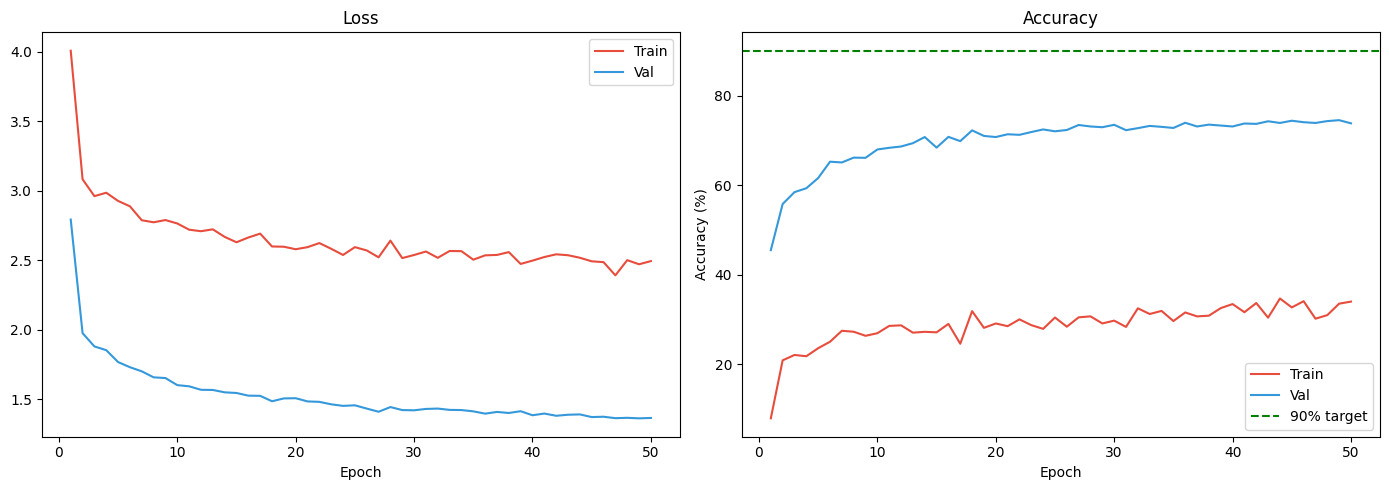

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], label='Train', color='#e74c3c')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#3498db')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep, history['train_acc'], label='Train', color='#e74c3c')
axes[1].plot(ep, history['val_acc'],   label='Val',   color='#3498db')
axes[1].axhline(90, color='green', linestyle='--', label='90% target')
axes[1].set_title('Accuracy'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/training_curves.png", dpi=150)
plt.show()

## Cell 12 — Test Evaluation with TTA

In [12]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded epoch {ckpt['epoch']}  val_acc={ckpt['val_acc']:.2f}%")


@torch.no_grad()
def evaluate_tta(model, paths, labels, n_tta=6):
    model.eval()
    all_preds, all_probs = [], []
    for path in tqdm(paths, desc='TTA Inference'):
        img   = np.array(Image.open(path).convert('RGB'))
        views = torch.stack(
            [tta_transform(image=img)['image'] for _ in range(n_tta)]
        ).to(DEVICE).float()
        with torch.amp.autocast('cuda', enabled=DEVICE.type=='cuda'):
            logits = model(views)
        probs = F.softmax(logits, dim=1).mean(0)
        all_preds.append(probs.argmax().item())
        all_probs.append(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_probs)


test_preds, test_probs = evaluate_tta(model, test_paths, test_labels,
                                       CFG['TTA_AUGMENTS'])
test_acc = 100. * (test_preds == test_labels).mean()
print(f'\n🎯 Test Accuracy (TTA x{CFG["TTA_AUGMENTS"]}): {test_acc:.2f}%')
print('\n', classification_report(
    test_labels, test_preds, target_names=class_names, digits=3))

Loaded epoch 49  val_acc=74.49%


TTA Inference: 100%|██████████| 2416/2416 [04:50<00:00,  8.32it/s]


🎯 Test Accuracy (TTA x6): 73.92%

                       precision    recall  f1-score   support

           aloo_gobi      0.846     0.733     0.786        30
          aloo_tikki      0.600     0.360     0.450        25
               appam      0.758     0.893     0.820        28
               barfi      0.579     0.815     0.677        27
           bhel_puri      0.630     0.586     0.607        29
             biryani      0.941     0.800     0.865        60
        bread_pakora      0.778     0.700     0.737        30
              burger      0.821     0.852     0.836        27
      butter_chicken      0.421     0.593     0.492        27
               chaat      0.417     0.517     0.462        29
       chicken_curry      0.480     0.400     0.436        30
       chole_bhature      0.967     0.702     0.814        84
              dabeli      0.895     0.630     0.739        27
          dal_dhokli      0.697     0.793     0.742        29
         dal_makhani      0.844  

## Cell 13 — Confusion Matrix

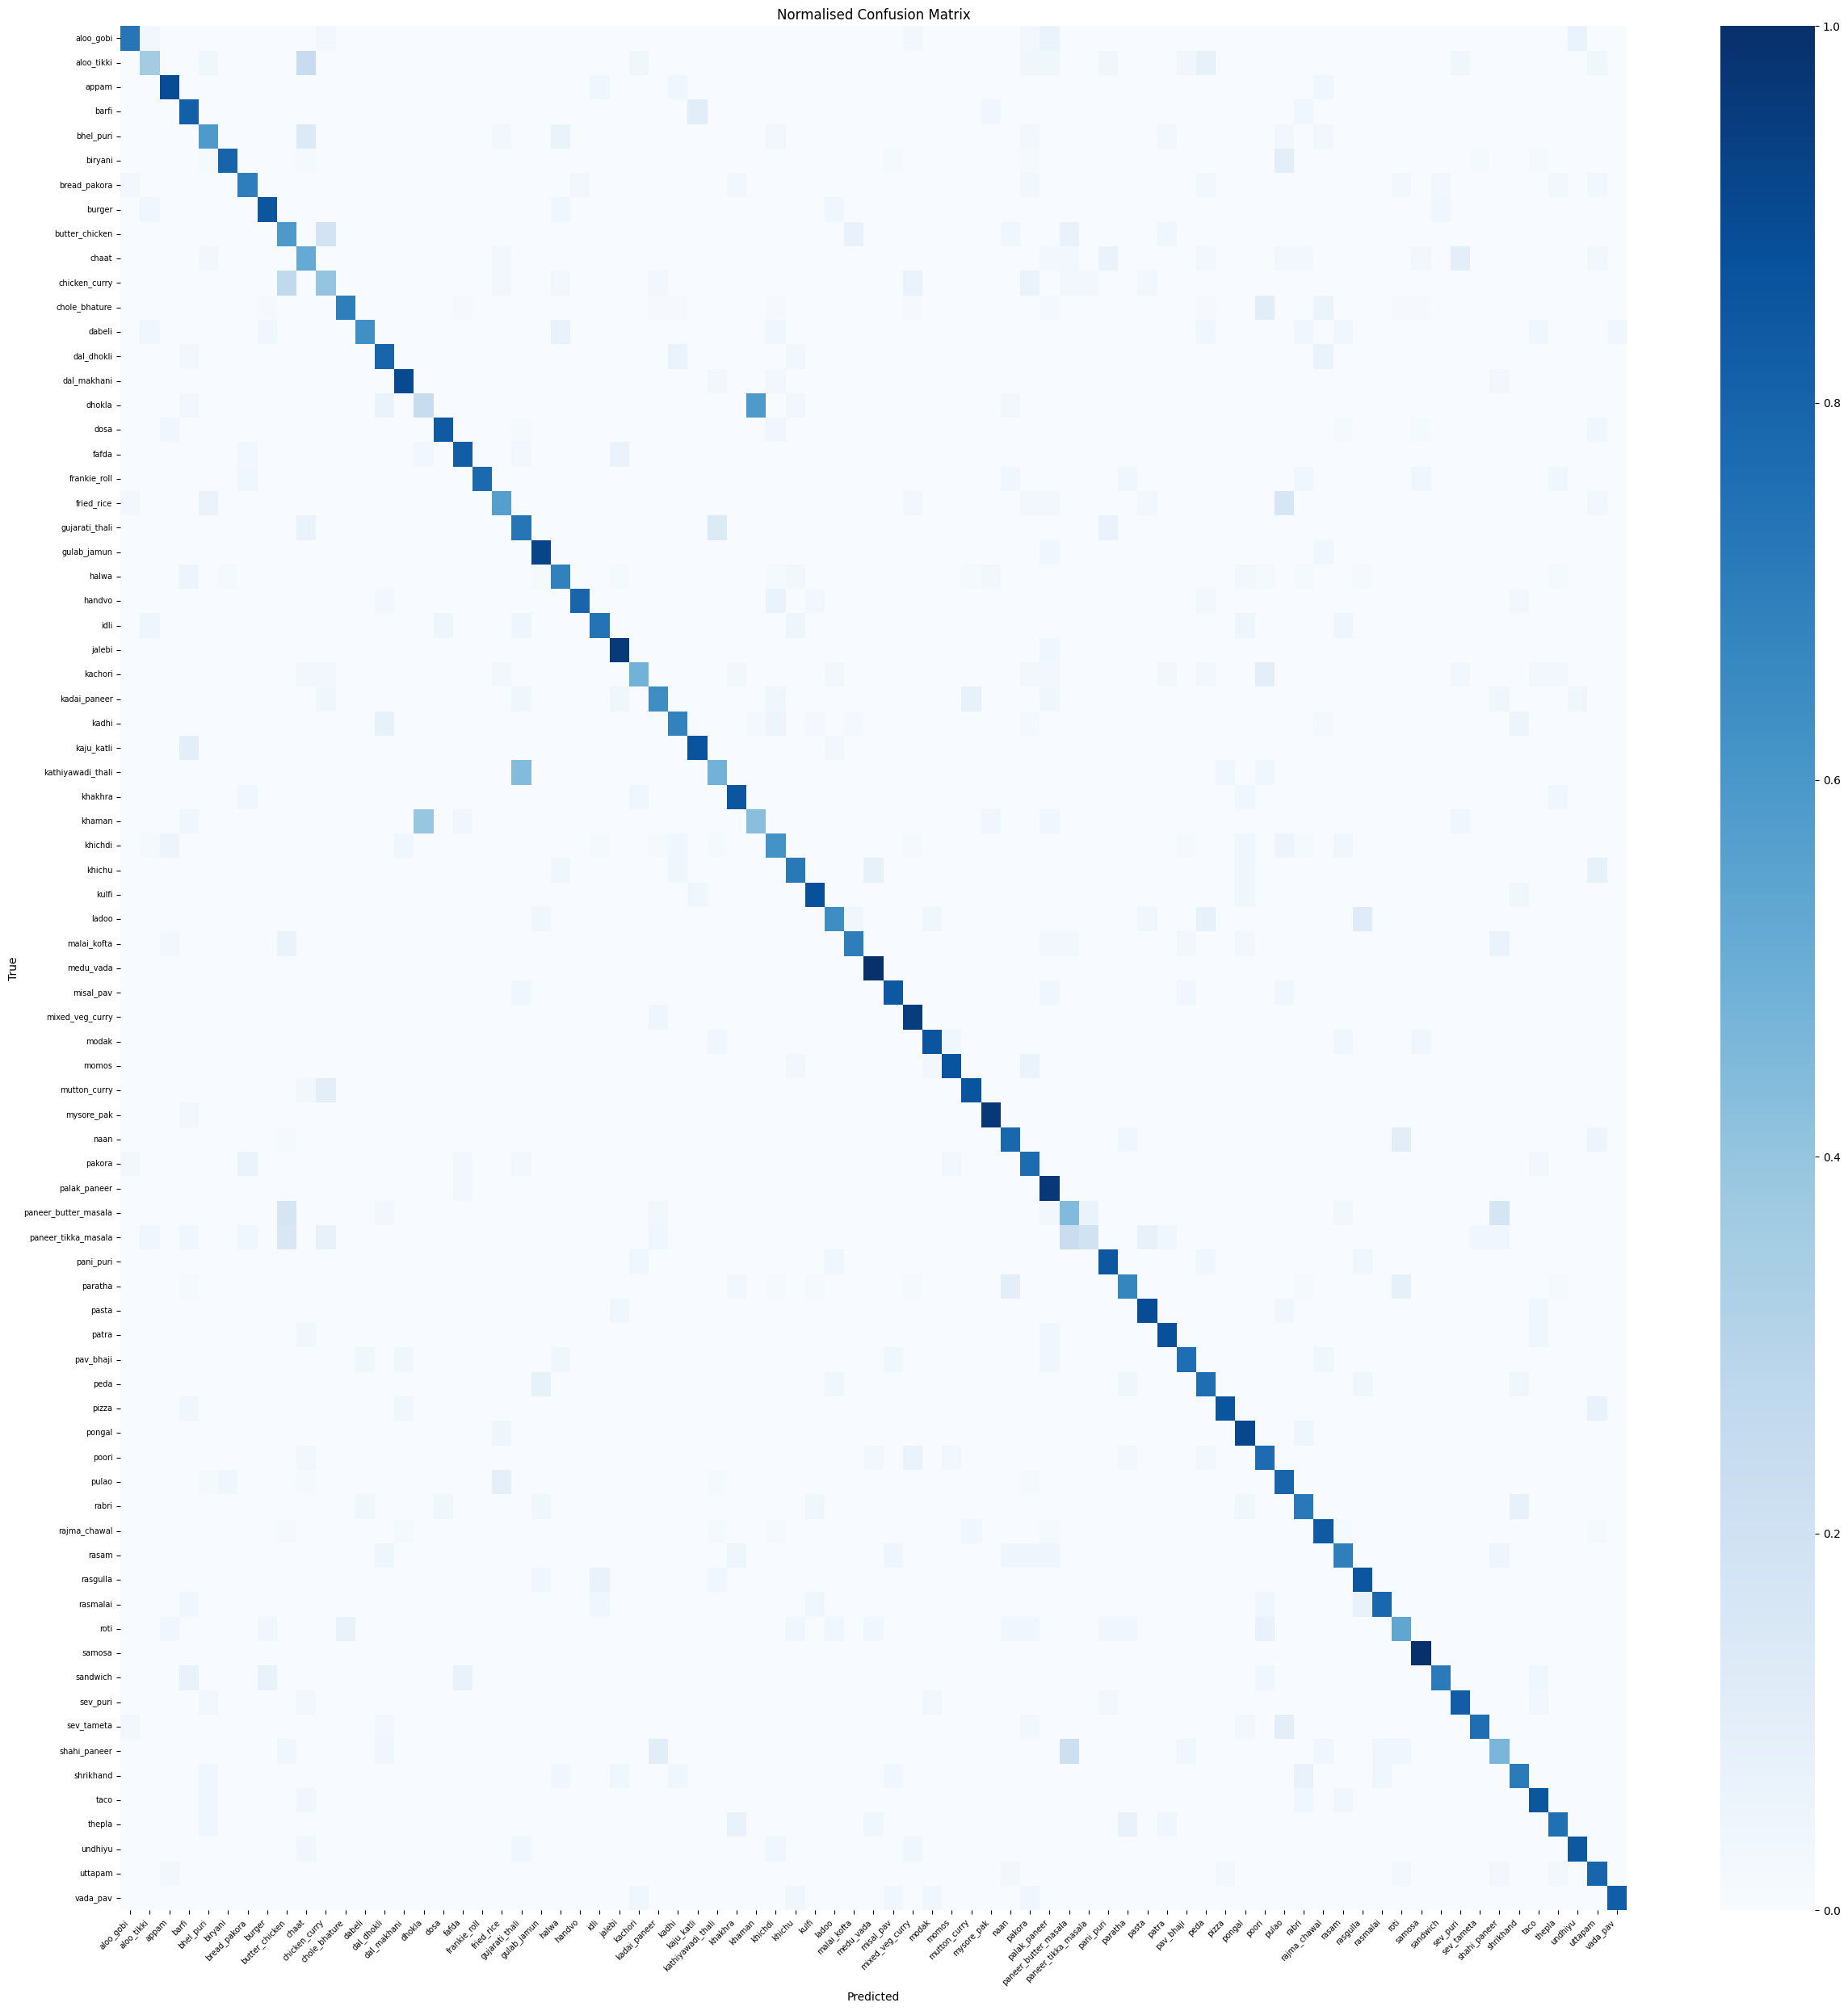

Top-10 Confused Pairs:
  dhokla                         → khaman                          (17)
  kathiyawadi_thali              → gujarati_thali                  (12)
  khaman                         → dhokla                          (11)
  chole_bhature                  → poori                           (9)
  chicken_curry                  → butter_chicken                  (8)
  shahi_paneer                   → paneer_butter_masala            (6)
  paratha                        → naan                            (6)
  paneer_tikka_masala            → paneer_butter_masala            (6)
  naan                           → roti                            (6)
  biryani                        → pulao                           (6)


In [13]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

h = max(14, NUM_CLASSES//3)
fig, ax = plt.subplots(figsize=(h, h))
sns.heatmap(cm_norm, annot=False, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=ax, vmin=0, vmax=1)
ax.set_title('Normalised Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/confusion_matrix.png", dpi=150)
plt.show()

pairs = sorted(
    [(cm[i,j], class_names[i], class_names[j])
     for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
     if i!=j and cm[i,j]>0], reverse=True)
print('Top-10 Confused Pairs:')
for cnt, t, p in pairs[:10]:
    print(f'  {t:30s} → {p:30s}  ({cnt})')

## Cell 14 — Per-Class Accuracy

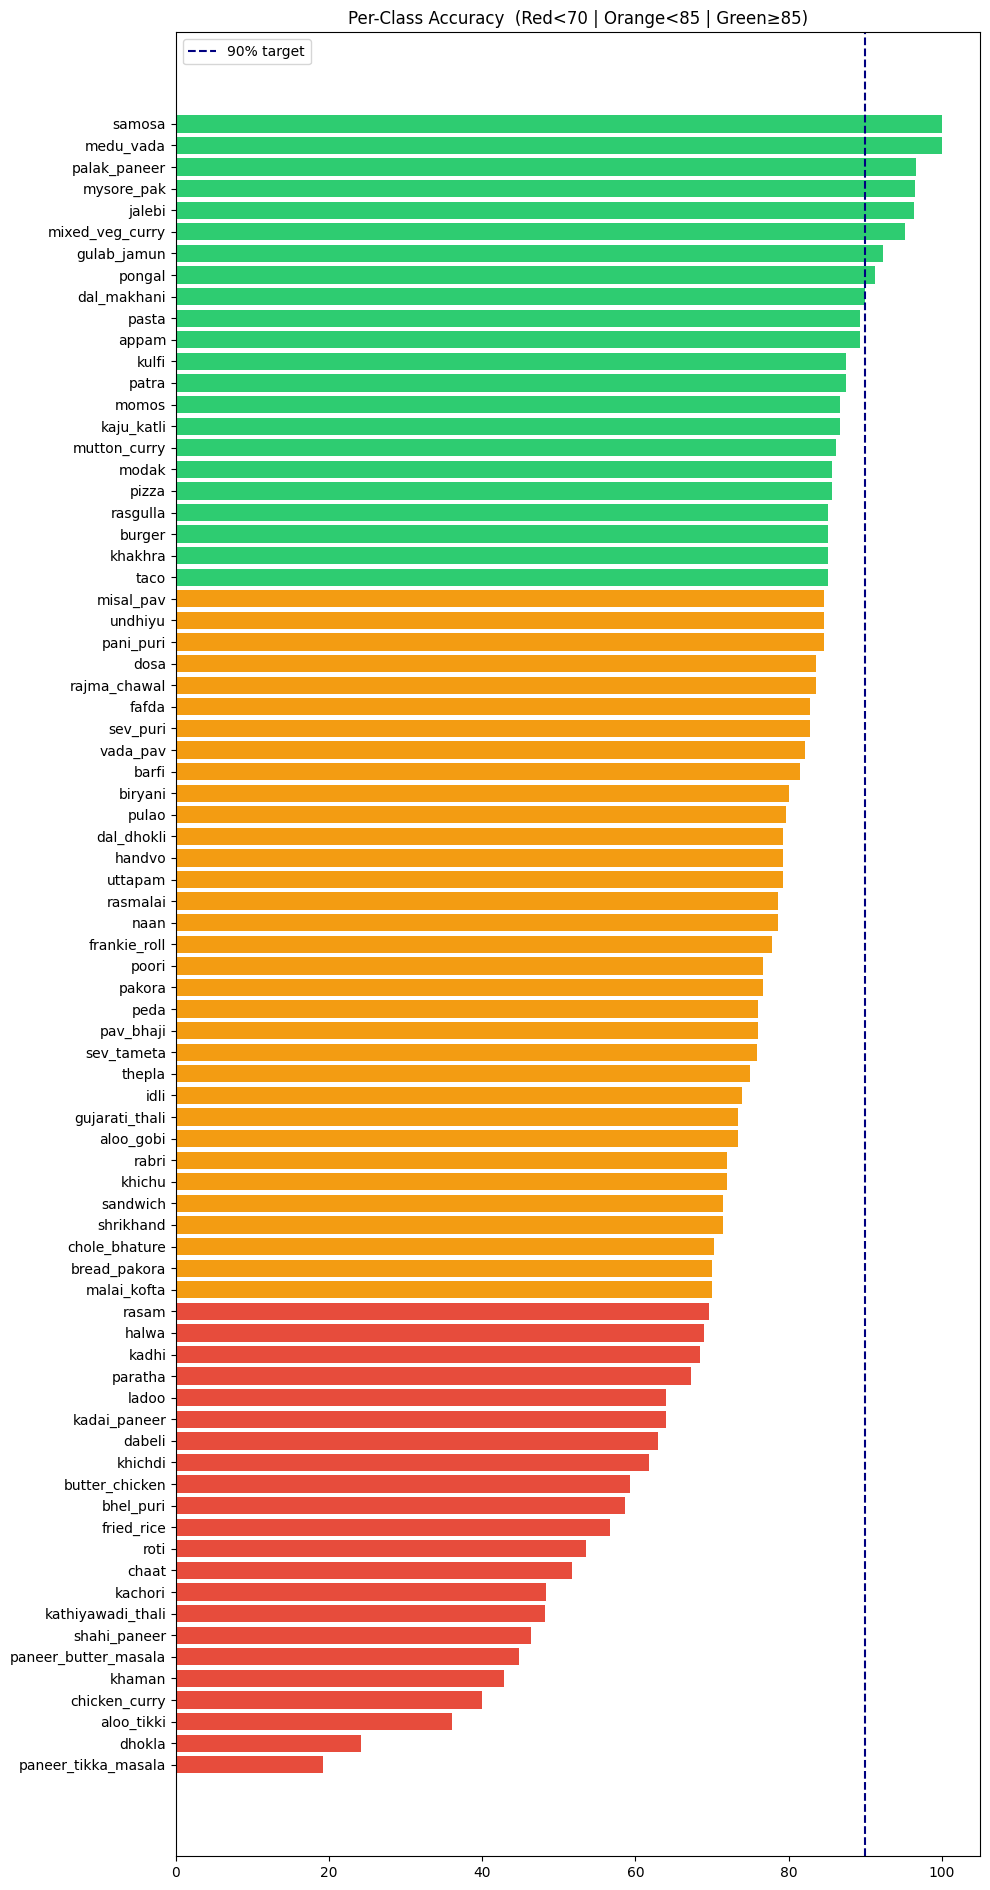

Classes below 80% (45):
               Class  Accuracy
 paneer_tikka_masala 19.230769
              dhokla 24.137931
          aloo_tikki 36.000000
       chicken_curry 40.000000
              khaman 42.857143
paneer_butter_masala 44.827586
        shahi_paneer 46.428571
   kathiyawadi_thali 48.148148
             kachori 48.275862
               chaat 51.724138
                roti 53.571429
          fried_rice 56.666667
           bhel_puri 58.620690
      butter_chicken 59.259259
             khichdi 61.818182
              dabeli 62.962963
        kadai_paneer 64.000000
               ladoo 64.000000
             paratha 67.241379
               kadhi 68.421053
               halwa 68.965517
               rasam 69.565217
         malai_kofta 70.000000
        bread_pakora 70.000000
       chole_bhature 70.238095
           shrikhand 71.428571
            sandwich 71.428571
              khichu 72.000000
               rabri 72.000000
           aloo_gobi 73.333333
      gujarati_

In [14]:
pca = cm.diagonal() / cm.sum(axis=1)
df  = pd.DataFrame({'Class': class_names,
                     'Accuracy': pca*100}).sort_values('Accuracy')

fig, ax = plt.subplots(figsize=(10, max(8, NUM_CLASSES//4)))
colors  = ['#e74c3c' if a<70 else '#f39c12' if a<85 else '#2ecc71'
           for a in df['Accuracy']]
ax.barh(df['Class'], df['Accuracy'], color=colors)
ax.axvline(90, color='navy', linestyle='--', label='90% target')
ax.set_xlim(0, 105); ax.legend()
ax.set_title('Per-Class Accuracy  (Red<70 | Orange<85 | Green≥85)')
plt.tight_layout()
plt.savefig(f"{CFG['LOG_DIR']}/per_class_acc.png", dpi=150)
plt.show()

weak = df[df['Accuracy'] < 80]
if len(weak):
    print(f'Classes below 80% ({len(weak)}):')
    print(weak.to_string(index=False))
else:
    print('All classes above 80%!')

## Cell 15 — Single Image Inference

True label: fried_rice


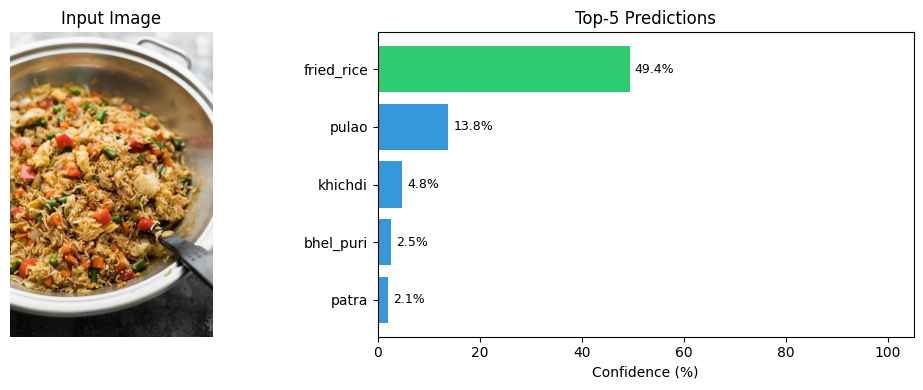


🏆 fried_rice  (49.4% confidence)


[('fried_rice', 49.365234375),
 ('pulao', 13.78173828125),
 ('khichdi', 4.7607421875),
 ('bhel_puri', 2.54058837890625),
 ('patra', 2.0782470703125)]

In [54]:
@torch.no_grad()
def predict(img_path, n_tta=6, top_k=5):
    model.eval()
    img   = np.array(Image.open(img_path).convert('RGB'))
    views = torch.stack(
        [tta_transform(image=img)['image'] for _ in range(n_tta)]
    ).to(DEVICE).float()
    with torch.amp.autocast('cuda', enabled=DEVICE.type=='cuda'):
        logits = model(views)
    probs          = F.softmax(logits, 1).mean(0)
    topk_p, topk_i = probs.topk(top_k)
    results = [(class_names[i.item()], p.item()*100)
               for i, p in zip(topk_i, topk_p)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.imshow(Image.open(img_path).convert('RGB'))
    ax1.axis('off'); ax1.set_title('Input Image')

    names  = [r[0] for r in results]
    scores = [r[1] for r in results]
    cols   = ['#2ecc71' if i==0 else '#3498db' for i in range(len(names))]
    ax2.barh(names[::-1], scores[::-1], color=cols[::-1])
    ax2.set_xlim(0, 105); ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f'Top-{top_k} Predictions')
    for i, (n, s) in enumerate(zip(names[::-1], scores[::-1])):
        ax2.text(s+1, i, f'{s:.1f}%', va='center', fontsize=9)
    plt.tight_layout(); plt.show()
    print(f'\n🏆 {results[0][0]}  ({results[0][1]:.1f}% confidence)')
    return results


# Demo on a random test image
idx = random.randint(0, len(test_paths)-1)
print(f'True label: {class_names[test_labels[idx]]}')
predict(test_paths[idx])

## Cell 16 — Export TorchScript

In [16]:
model.eval()
dummy  = torch.randn(1, 3, SZ, SZ, device=DEVICE)
traced = torch.jit.trace(model, dummy)
ts_path = f"{CFG['CHECKPOINT_DIR']}/indian_food_v3.pt"
traced.save(ts_path)
print(f'TorchScript saved: {ts_path}')
out = torch.jit.load(ts_path).to(DEVICE).eval()(dummy)
print(f'Output shape: {out.shape}  ← should be (1, {NUM_CLASSES})')

TorchScript saved: ./checkpoints/indian_food_v3.pt
Output shape: torch.Size([1, 77])  ← should be (1, 77)


## Cell 17 — Save Pickle Artifacts


Pickle saved: ./checkpoints/class_names.pkl
Pickle saved: ./checkpoints/class_mapping.pkl


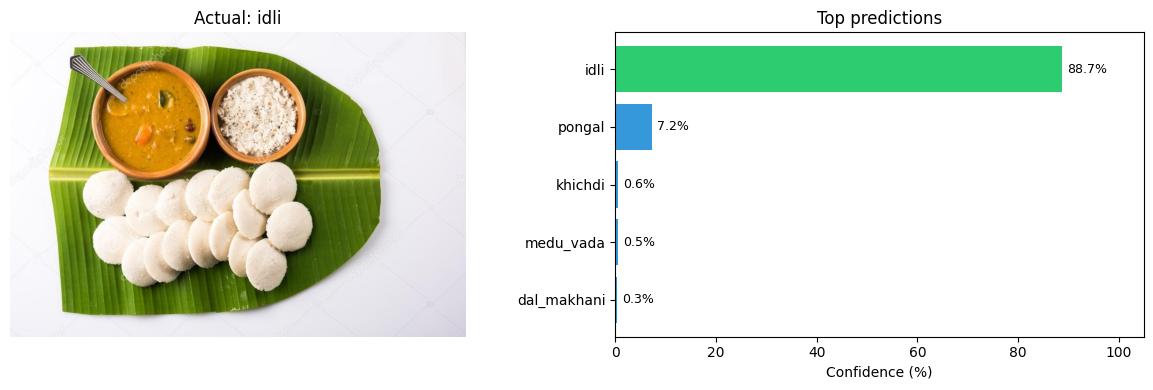

Random image : food_dataset\idli\idli_9.jpg
Actual       : idli
Predicted    : idli (88.7%)


In [51]:
import pickle

# Save lightweight pickle artifacts for reuse in other apps/scripts
pickle_path = f"{CFG['CHECKPOINT_DIR']}/class_names.pkl"
with open(pickle_path, 'wb') as f:
    pickle.dump(class_names, f)

mapping_pickle_path = f"{CFG['CHECKPOINT_DIR']}/class_mapping.pkl"
with open(mapping_pickle_path, 'wb') as f:
    pickle.dump(
        {
            'class_to_idx': class_to_idx,
            'idx_to_class': {v: k for k, v in class_to_idx.items()},
        },
        f,
    )

print(f'Pickle saved: {pickle_path}')
print(f'Pickle saved: {mapping_pickle_path}')


@torch.no_grad()
def predict_random_sample(paths, labels, n_tta=6, top_k=5):
    """Pick a random image, predict it, and show actual vs predicted labels."""
    idx = random.randint(0, len(paths) - 1)
    img_path = paths[idx]
    true_idx = int(labels[idx])
    true_label = class_names[true_idx]

    img = np.array(Image.open(img_path).convert('RGB'))
    views = torch.stack([
        tta_transform(image=img)['image'] for _ in range(n_tta)
    ]).to(DEVICE).float()

    with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
        logits = model(views)

    probs = F.softmax(logits, dim=1).mean(0)
    pred_idx = probs.argmax().item()
    pred_label = class_names[pred_idx]
    pred_conf = probs[pred_idx].item() * 100

    topk_p, topk_i = probs.topk(top_k)
    topk_results = [(class_names[i.item()], p.item() * 100) for i, p in zip(topk_i, topk_p)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.imshow(Image.open(img_path).convert('RGB'))
    ax1.axis('off')
    ax1.set_title(f'Actual: {true_label}')

    names = [name for name, _ in topk_results]
    scores = [score for _, score in topk_results]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(names))]
    ax2.barh(names[::-1], scores[::-1], color=colors[::-1])
    ax2.set_xlim(0, 105)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('Top predictions')
    for i, (name, score) in enumerate(zip(names[::-1], scores[::-1])):
        ax2.text(score + 1, i, f'{score:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f'Random image : {img_path}')
    print(f'Actual       : {true_label}')
    print(f'Predicted    : {pred_label} ({pred_conf:.1f}%)')
    return {
        'image_path': str(img_path),
        'actual': true_label,
        'predicted': pred_label,
        'confidence': pred_conf,
        'topk': topk_results,
    }


# Demo: predict one random image from the test split
random_result = predict_random_sample(test_paths, test_labels, n_tta=CFG['TTA_AUGMENTS'])

In [55]:
import pickle

with open('./nutrition_mapping.pkl', 'rb') as f:
    data = pickle.load(f)

print(type(data))
print()

# Show first 3 food entries with all their fields
for i, (food, values) in enumerate(list(data.items())[:3]):
    print(f"Food: {food}")
    print(f"Data: {values}")
    print()

<class 'dict'>

Food: aloo_gobi
Data: {'calories': None, 'protein': None, 'carbs': None, 'fat': None, 'sugar': None}

Food: aloo_paratha
Data: {'calories': None, 'protein': None, 'carbs': None, 'fat': None, 'sugar': None}

Food: aloo_tikki
Data: {'calories': None, 'protein': None, 'carbs': None, 'fat': None, 'sugar': None}

